# 01 - Data Quality Assessment

This notebook performs the following tasks for the `raw_credit_applications.json` dataset:

- Identified and documented data quality issues (completeness, consistency, validity, accuracy).
- Quantified the extent of each issue (e.g., number of affected records, percentage).
- Proposed and demonstrated remediation steps.

---
---

## Dataset - Expected Schema

| Field                   | Type    | Description                                     |
| ----------------------- | ------- | ----------------------------------------------- |
| `_id`                   | `str`   | Application ID (e.g., app_001)                  |
| `full_name` *(PII)*     | `str`   | Applicant full name                             |
| `email` *(PII)*         | `str`   | Email address                                   |
| `ssn` *(PII)*           | `str`   | Social Security Number - `NNN-NN-NNNN`          |
| `ip_address` *(PII)*    | `str`   | IP address at time of application               |
| `gender`                | `str`   | Gender - `Male` or `Female`                     |
| `date_of_birth` *(PII)* | `date`  | Date of birth (`YYYY-MM-DD`)                    |
| `age`                   | `int`   | Applicant age (derived from `date_of_birth`)    |
| `zip_code`              | `str`   | ZIP/postal code                                 |
| `annual_income`         | `float` | Annual income `> 0`                             |
| `credit_history_months` | `int`   | Months of credit history `≥ 0`                  |
| `debt_to_income`        | `float` | Debt-to-income ratio `0 - 1.0`                  |
| `savings_balance`       | `float` | Current savings balance `≥ 0`                   |
| `loan_approved`         | `bool`  | `TRUE` or `FALSE`                               |
| `rejection_reason`      | `str`   | Reason (if denied)                              |
| `loan_purpose`          | `str`   | Purpose of the loan (if approved)               |
| `interest_rate`         | `float` | Assigned rate (if approved)                     |
| `approved_amount`       | `float` | Loan amount (if approved)                       |
| `spend_<Category>`      | `float` | Spending by category `≥ 0` (pivot **spending_behavior**)|
| `processing_timestamp`  | `str`   | Timestamp of application processing             |


---
## Phase 0 - Setup

In [386]:
import json
import re
import warnings
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Environment ready")

✅ Environment ready


---

## Phase 1 - Loading & Normalization

**Goal:** Transform the nested JSON into a tabular DataFrame. Spending categories become individual columns (`spend_<Category>`) for feature engineering.


In [387]:
# 1‑A  Load JSON
with open("../data/raw_credit_applications.json", "r") as f:
    raw_data = json.load(f)

print(f"Records loaded: {len(raw_data):,}")
print(f"Top‑level keys (first record): {list(raw_data[0].keys())}")

Records loaded: 502
Top‑level keys (first record): ['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision', 'processing_timestamp']


In [388]:
# 1‑B  Flatten nested dicts
df_raw = pd.json_normalize(
    raw_data,
    sep="_",                          # applicant_info_full_name, etc.
    errors="ignore",
)

# Rename flattened columns to cleaner names
rename_map = {c: c.replace("applicant_info_", "").replace("financials_", "").replace("decision_", "")
              for c in df_raw.columns}
df_raw.rename(columns=rename_map, inplace=True)

print(f"Shape after flatten: {df_raw.shape}")
df_raw.head(3)

Shape after flatten: (502, 21)


,_id,spending_behavior,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN


In [389]:
# 1‑C  Pivot spending_behavior into spend_<Category> columns
def pivot_spending(row):
    """Convert spending_behavior (list of dicts) into dicts keyed by category."""
    result = {}
    if isinstance(row, list):
        for item in row:
            cat = item.get("category", "Unknown")
            amt = item.get("amount", 0)
            result[f"spend_{cat.replace(' ', '_')}"] = amt
    return pd.Series(result)

spend_df = df_raw["spending_behavior"].apply(pivot_spending)
df = pd.concat([df_raw.drop(columns=["spending_behavior"]), spend_df], axis=1)

# Fill NaN spend columns with 0 (means didn't spend in that category)
spend_cols = [c for c in df.columns if c.startswith("spend_")]
df[spend_cols] = df[spend_cols].fillna(0).astype(float)

print(f"Shape after pivoting spending: {df.shape}")
print(f"Spending columns created: {spend_cols}")
df.head(3)

Shape after pivoting spending: (502, 35)
Spending columns created: ['spend_Shopping', 'spend_Rent', 'spend_Alcohol', 'spend_Dining', 'spend_Healthcare', 'spend_Fitness', 'spend_Entertainment', 'spend_Insurance', 'spend_Travel', 'spend_Transportation', 'spend_Utilities', 'spend_Groceries', 'spend_Education', 'spend_Adult_Entertainment', 'spend_Gambling']


,_id,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,annual_salary,notes,spend_Shopping,spend_Rent,spend_Alcohol,spend_Dining,spend_Healthcare,spend_Fitness,spend_Entertainment,spend_Insurance,spend_Travel,spend_Transportation,spend_Utilities,spend_Groceries,spend_Education,spend_Adult_Entertainment,spend_Gambling
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,480.0,790.0,247.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,78000,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,0.0,608.0,0.0,96.0,243.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN,0.0,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
## Phase 2 - Data Quality Audit

Following **Detect → Quantify → Fix** cycle. 
---

### Dimension 1 - Accuracy

In [390]:
# 2.1  DETECT Duplicate _id values
dup_ids = df[df.duplicated(subset="_id", keep=False)].sort_values("_id")
print(f"🔍 Duplicate _id records found: {len(dup_ids)}")
dup_ids[["_id", "full_name", "loan_approved", "rejection_reason", "notes"]]

🔍 Duplicate _id records found: 4


,_id,full_name,loan_approved,rejection_reason,notes
383,app_001,Stephanie Nguyen,False,high_dti_ratio,NaN
455,app_001,Stephanie Nguyen,False,high_dti_ratio,DUPLICATE_ENTRY_ERROR
8,app_042,Joseph Lopez,False,algorithm_risk_score,NaN
354,app_042,Joseph Lopez,False,algorithm_risk_score,RESUBMISSION


In [391]:
# 2.1  QUANTIFY
print(f"Total records before dedup: {len(df)}")
print(f"Unique _ids:               {df['_id'].nunique()}")
print(f"Duplicated rows:           {df.duplicated(subset='_id').sum()}")
print()

# Show the notes field
for _, row in dup_ids.iterrows():
    note = row.get("notes", "—")
    print(f"  {row['_id']}  notes={note}")

Total records before dedup: 502
Unique _ids:               500
Duplicated rows:           2

  app_001  notes=nan
  app_001  notes=DUPLICATE_ENTRY_ERROR
  app_042  notes=nan
  app_042  notes=RESUBMISSION


In [392]:
# 2.1  FIX - Drop duplicates using the notes
#   DUPLICATE_ENTRY_ERROR  -> discard (data‑entry mistake)
#   RESUBMISSION           -> keep the resubmission (latest intent)
#   No notes               -> keep the first occurrence

df = df[df["notes"] != "DUPLICATE_ENTRY_ERROR"].copy()
df = df.drop_duplicates(subset="_id", keep="last").reset_index(drop=True)  #dropping duplicates keeping last (drops dup_e_e)

# Drop the notes column
df.drop(columns=["notes"], inplace=True, errors="ignore")

print(f"✅ Records after dedup: {len(df)} (removed {502 - len(df)} duplicates)")

✅ Records after dedup: 500 (removed 2 duplicates)


---
### Dimension 2 - Consistency

In [393]:
# 2.2‑A  DETECT - Inconsistent gender coding
print("🔍 Gender value counts (before):")
print(df["gender"].value_counts(dropna=False))

🔍 Gender value counts (before):
gender
Male      194
Female    193
F          58
M          53
            2
Name: count, dtype: int64


In [394]:
# 2.2‑A  FIX - Standardise gender to Male / Female / Unknown
gender_map = {
    "M": "Male",
    "F": "Female",
    "Male": "Male",
    "Female": "Female",
}
df["gender"] = df["gender"].map(gender_map).fillna("Unknown")

print("✅ Gender value counts (after):")
print(df["gender"].value_counts())

✅ Gender value counts (after):
gender
Female     251
Male       247
Unknown      2
Name: count, dtype: int64


In [395]:
# 2.2‑B  DETECT - Income schema mistakes
#  Some records store income under 'annual_salary' instead of 'annual_income'
#  Some store annual_income as a string or float

if "annual_salary" in df.columns:
    salary_mask = df["annual_salary"].notna()
    print(f"🔍 Records using 'annual_salary' key: {salary_mask.sum()}")
else:
    salary_mask = pd.Series(False, index=df.index)
    print("🔍 No 'annual_salary' column found")

# Check types in annual_income
print(f"\n   annual_income dtype: {df['annual_income'].dtype}")
print("   Sample non‑numeric values:")
for idx, val in df["annual_income"].items():
    if isinstance(val, str):
        print(f"     Row {idx} (_id={df.loc[idx, '_id']}): '{val}' (str)")

🔍 Records using 'annual_salary' key: 5

   annual_income dtype: object
   Sample non‑numeric values:
     Row 91 (_id=app_088): '55000' (str)
     Row 145 (_id=app_135): '65000' (str)
     Row 170 (_id=app_446): '73000' (str)
     Row 305 (_id=app_389): '51000' (str)
     Row 333 (_id=app_026): '72000' (str)
     Row 430 (_id=app_312): '80000' (str)
     Row 446 (_id=app_180): '111000' (str)
     Row 488 (_id=app_224): '93000' (str)


In [396]:
# 2.2‑B  FIX - Merge annual_salary and annual_income, turn to numeric
if "annual_salary" in df.columns:
    # Fill missing annual_income with annual_salary when available
    df["annual_income"] = df["annual_income"].fillna(df["annual_salary"])
    df.drop(columns=["annual_salary"], inplace=True)

# To numeric (strings to float, invalid to NaN)
df["annual_income"] = pd.to_numeric(df["annual_income"], errors="coerce")

print(f"✅ annual_income dtype: {df['annual_income'].dtype}")
print(f"   Null count after coercion: {df['annual_income'].isna().sum()}")
print(f"   Range: {df['annual_income'].min():,.0f} – {df['annual_income'].max():,.0f}")

✅ annual_income dtype: float64
   Null count after coercion: 0
   Range: 0 – 171,000


In [397]:
# 2.2‑C  DETECT - Inconsistent date‑of‑birth formats
print("🔍 Sample date_of_birth values (raw):")
sample_dobs = df["date_of_birth"].dropna().unique()
np.random.seed(42)
for dob in np.random.choice(sample_dobs, size=min(12, len(sample_dobs)), replace=False):
    print(f"   {dob}")

# Quick regex classification
fmt_counts = {"YYYY-MM-DD": 0, "DD/MM/YYYY": 0, "YYYY/MM/DD": 0, "empty/null": 0, "other": 0}
for dob in df["date_of_birth"]:
    if pd.isna(dob) or str(dob).strip() == "":
        fmt_counts["empty/null"] += 1
    elif re.match(r"^\d{4}-\d{2}-\d{2}$", str(dob)):
        fmt_counts["YYYY-MM-DD"] += 1
    elif re.match(r"^\d{2}/\d{2}/\d{4}$", str(dob)):
        fmt_counts["DD/MM/YYYY"] += 1
    elif re.match(r"^\d{4}/\d{2}/\d{2}$", str(dob)):
        fmt_counts["YYYY/MM/DD"] += 1
    else:
        fmt_counts["other"] += 1

print(f"\n🔍 Format distribution: {fmt_counts}")

🔍 Sample date_of_birth values (raw):
   1998-07-21
   11/03/1967
   18/03/1988
   1987-10-23
   1992-09-01
   13/06/1993
   1975-04-14
   1985-09-06
   24/10/1988
   1970-10-01
   1999/06/16
   1983-10-26

🔍 Format distribution: {'YYYY-MM-DD': 339, 'DD/MM/YYYY': 101, 'YYYY/MM/DD': 56, 'empty/null': 4, 'other': 0}


In [398]:
# 2.2‑C  FIX - Parse all dates to ISO 8601 and derive age

def parse_dob(dob_str):
    """Attempt multiple date formats and return a datetime or NaT."""
    if pd.isna(dob_str) or str(dob_str).strip() == "":
        return pd.NaT

    dob_str = str(dob_str).strip()

    # Try YYYY-MM-DD and YYYY/MM/DD
    for fmt in ("%Y-%m-%d", "%Y/%m/%d"):
        try:
            return datetime.strptime(dob_str, fmt)
        except ValueError:
            pass

    # DD/MM/YYYY (day‑first)
    if re.match(r"^\d{2}/\d{2}/\d{4}$", dob_str):
        try:
            return datetime.strptime(dob_str, "%d/%m/%Y")
        except ValueError:
            pass

    return pd.NaT

df["date_of_birth"] = df["date_of_birth"].apply(parse_dob)
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"])

# Derive age (in 2024‑01‑15, the processing date in the data)
reference_date = pd.Timestamp("2024-01-15")
df["age"] = ((reference_date - df["date_of_birth"]).dt.days / 365.25).apply(
    lambda x: int(round(x)) if pd.notna(x) else pd.NA
).astype("Int64")

print(f"✅ date_of_birth dtype: {df['date_of_birth'].dtype}")
print(f"   Null DOBs: {df['date_of_birth'].isna().sum()}")
print(f"   Age range: {df['age'].min()} – {df['age'].max()}")
df[["_id", "date_of_birth", "age"]].head(8)


✅ date_of_birth dtype: datetime64[ns]
   Null DOBs: 30
   Age range: 22 – 65


,_id,date_of_birth,age
0,app_200,2001-03-09,23
1,app_037,1992-03-31,32
2,app_215,1989-10-24,34
3,app_024,1983-04-25,41
4,app_184,1999-05-21,25
5,app_275,1982-02-14,42
6,app_099,1990-01-28,34
7,app_246,1991-10-11,32


---
### Dimension 3 - Validity

In [399]:
# 2.3  DETECT - Impossible/invalid financial values

issues = []

# Negative credit_history_months
mask_neg_ch = df["credit_history_months"] < 0
issues.append(("credit_history_months < 0", mask_neg_ch.sum(),
               df.loc[mask_neg_ch, ["_id", "credit_history_months"]]))

# Negative savings_balance
mask_neg_sb = df["savings_balance"] < 0
issues.append(("savings_balance < 0", mask_neg_sb.sum(),
               df.loc[mask_neg_sb, ["_id", "savings_balance"]]))

# DTI > 1.0
mask_high_dti = df["debt_to_income"] > 1.0
issues.append(("debt_to_income > 1.0", mask_high_dti.sum(),
               df.loc[mask_high_dti, ["_id", "debt_to_income"]]))

# Zero annual income
mask_zero_inc = df["annual_income"] == 0
issues.append(("annual_income == 0", mask_zero_inc.sum(),
               df.loc[mask_zero_inc, ["_id", "annual_income"]]))

for label, count, detail in issues:
    print(f"🔍 {label}: {count} record(s)")
    if count > 0:
        print(detail.to_string(index=False))
    print()

🔍 credit_history_months < 0: 2 record(s)
    _id  credit_history_months
app_043                    -10
app_156                     -3

🔍 savings_balance < 0: 1 record(s)
    _id  savings_balance
app_290            -5000

🔍 debt_to_income > 1.0: 1 record(s)
    _id  debt_to_income
app_402            1.85

🔍 annual_income == 0: 1 record(s)
    _id  annual_income
app_190            0.0



In [400]:
# 2.3  FIX - Replace invalid values with NaN (will impute later)
df.loc[df["credit_history_months"] < 0, "credit_history_months"] = np.nan
df.loc[df["savings_balance"] < 0, "savings_balance"] = np.nan
df.loc[df["debt_to_income"] > 1.0, "debt_to_income"] = np.nan
df.loc[df["annual_income"] == 0, "annual_income"] = np.nan

print("✅ Invalid financial values set to NaN, ready for impute")

✅ Invalid financial values set to NaN, ready for impute


In [401]:
# 2.3  LOGIC - rejection_reason must be null when loan_approved == True
approved_with_rej = df[(df["loan_approved"] == True) & (df["rejection_reason"].notna())]
rejected_without_rej = df[(df["loan_approved"] == False) & (df["rejection_reason"].isna())]

print(f"Approved but has rejection_reason: {len(approved_with_rej)}")
print(f"Rejected but missing rejection_reason: {len(rejected_without_rej)}")

print("\nLogic check complete")

Approved but has rejection_reason: 0
Rejected but missing rejection_reason: 0

Logic check complete


---
### Dimension 4 - Completeness

In [402]:
# 2.4  DETECT - Missing value matrix
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"null_count": missing, "null_pct": missing_pct})
missing_report = missing_report[missing_report["null_count"] > 0].sort_values("null_pct", ascending=False)

print(f"🔍 Columns with missing values: {len(missing_report)}")
missing_report

🔍 Columns with missing values: 13


,null_count,null_pct
loan_purpose,450,90.0
processing_timestamp,438,87.6
rejection_reason,292,58.4
approved_amount,208,41.6
interest_rate,208,41.6
age,30,6.0
date_of_birth,30,6.0
ssn,4,0.8
ip_address,4,0.8
credit_history_months,2,0.4


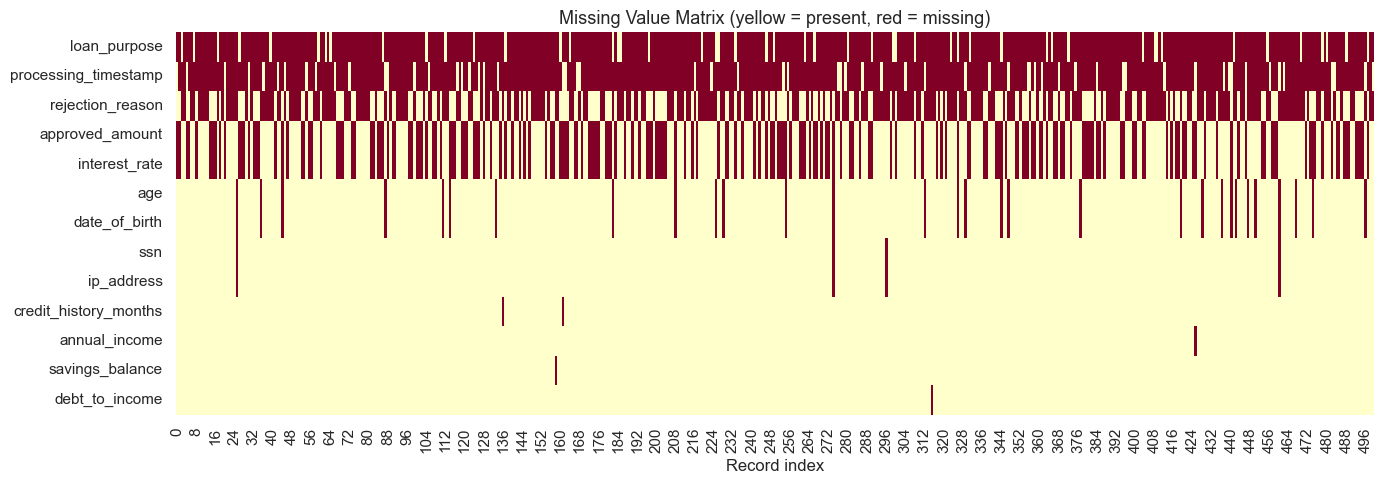

In [403]:
# 2.4  View missing value heatmap
fig, ax = plt.subplots(figsize=(14, 5))
cols_with_nulls = missing_report.index.tolist()
if cols_with_nulls:
    sns.heatmap(
        df[cols_with_nulls].isnull().T,
        cbar=False,
        yticklabels=True,
        cmap="YlOrRd",
        ax=ax,
    )
    ax.set_title("Missing Value Matrix (yellow = present, red = missing)", fontsize=13)
    ax.set_xlabel("Record index")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values")

In this Specific Case, it would be possible to have some entries more logically fixed (for example `debt_to_income`, for the one missing value, as it was 1.85, so it was probably a missclick and it meant to be 0.85). However, every mistake is unique and as we don't have enough data to calculate the others, for this workflow to work in any case, we opted to go with medians.

In [404]:
# 2.4  FIX - Missing values imputation (using median because mode outputs weird/unclean values)

# Numeric columns: median imputation
numeric_impute_cols = ["annual_income", "credit_history_months", "debt_to_income", "savings_balance"]
for col in numeric_impute_cols:
    if col in df.columns and df[col].isna().any():
        median_val = df[col].median()
        n_fill = df[col].isna().sum()
        df[col] = df[col].fillna(median_val)
        print(f"  - {col}: imputed {n_fill} nulls with median = {median_val:,.2f}")

# Categorical/string columns: fill with 'unknown'
for col in ["ip_address", "ssn", "loan_purpose", "processing_timestamp"]:
    if col in df.columns and df[col].isna().any():
        n_fill = df[col].isna().sum()
        df[col] = df[col].fillna("unknown")
        print(f"  - {col}: imputed {n_fill} nulls with 'unknown'")

print("\n✅ Imputation complete")
print(f"   Remaining nulls: {df.isnull().sum().sum()}")

  - annual_income: imputed 1 nulls with median = 81,000.00
  - credit_history_months: imputed 2 nulls with median = 49.00
  - debt_to_income: imputed 1 nulls with median = 0.23
  - savings_balance: imputed 1 nulls with median = 27,401.00
  - ip_address: imputed 4 nulls with 'unknown'
  - ssn: imputed 4 nulls with 'unknown'
  - loan_purpose: imputed 450 nulls with 'unknown'
  - processing_timestamp: imputed 438 nulls with 'unknown'

✅ Imputation complete
   Remaining nulls: 768


In [405]:
# 2.4  VERIFY - Missing value matrix
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"null_count": missing, "null_pct": missing_pct})
missing_report = missing_report[missing_report["null_count"] > 0].sort_values("null_pct", ascending=False)

print(f"🔍 Columns with missing values: {len(missing_report)}")
missing_report

🔍 Columns with missing values: 5


,null_count,null_pct
rejection_reason,292,58.4
approved_amount,208,41.6
interest_rate,208,41.6
date_of_birth,30,6.0
age,30,6.0


---

## Phase 3 - Data Governance & PII Identification

Columns that constitute **Personally Identifiable Information (PII)** are tagged below.  
Downstream `03-privacy-demo.ipynb` notebook will use this to mask PII.

In [406]:
# 3  PII column manifest
PII_COLUMNS = ["full_name", "email", "ssn", "ip_address", "date_of_birth"]

pii_manifest = pd.DataFrame({
    "column": PII_COLUMNS,
    "present_in_df": [c in df.columns for c in PII_COLUMNS],
    "non_null_count": [df[c].notna().sum() if c in df.columns else 0 for c in PII_COLUMNS],
    "classification": "PII",
    "action": "Must be anonymised/removed",
})

print("PII Manifest:")
pii_manifest

PII Manifest:


,column,present_in_df,non_null_count,classification,action
0,full_name,True,500,PII,Must be anonymised/removed
1,email,True,500,PII,Must be anonymised/removed
2,ssn,True,500,PII,Must be anonymised/removed
3,ip_address,True,500,PII,Must be anonymised/removed
4,date_of_birth,True,470,PII,Must be anonymised/removed


---
## Phase 4 - Clean Data Export

In [407]:
# 4‑A  Final checks
print("--- Final Dataset Summary ---")
print(f"  Shape:            {df.shape}")
print(f"  Unique _ids:      {df['_id'].nunique()}")
print(f"  Duplicate _ids:   {df.duplicated(subset='_id').sum()}")
print(f"  Gender values:    {df['gender'].unique().tolist()}")
print(f"  Income dtype:     {df['annual_income'].dtype}")
print(f"  DOB dtype:        {df['date_of_birth'].dtype}")
print(f"  Age range:        {df['age'].min()} – {df['age'].max()}")
print(f"  negative credit:  {(df['credit_history_months'] < 0).sum()}")
print(f"  negative savings: {(df['savings_balance'] < 0).sum()}")
print(f"  DTI > 1:          {(df['debt_to_income'] > 1).sum()}")
print(f"  Total NaN cells:  {df.isnull().sum().sum()}")

df.dtypes

--- Final Dataset Summary ---
  Shape:            (500, 34)
  Unique _ids:      500
  Duplicate _ids:   0
  Gender values:    ['Male', 'Female', 'Unknown']
  Income dtype:     float64
  DOB dtype:        datetime64[ns]
  Age range:        22 – 65
  negative credit:  0
  negative savings: 0
  DTI > 1:          0
  Total NaN cells:  768


_id                           object
processing_timestamp          object
full_name                     object
email                         object
ssn                           object
                              ...   
spend_Groceries              float64
spend_Education              float64
spend_Adult_Entertainment    float64
spend_Gambling               float64
age                            Int64
Length: 34, dtype: object

In [408]:
# Reorder columns: age as 8th column, processing_timestamp as last
cols = list(df.columns)
cols.remove("age")
cols.remove("processing_timestamp")
cols.insert(7, "age")
cols.append("processing_timestamp")
df = df[cols]

print("✅ Columns reordered")

✅ Columns reordered


In [409]:
# 4‑B  Export clean CSV
output_path = "../data/clean_credit_applications.csv"
df.to_csv(output_path, index=False)

print(f"Cleaned dataset exported to: {output_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

Cleaned dataset exported to: ../data/clean_credit_applications.csv
Rows: 500
Columns: 34


---
---

## Data Quality Audit - Summary of Findings

| #   | Dimension        | Issue                                                                   |        Affected  | Fix                                     |
| --- | ---------------- | ----------------------------------------------------------------------- | :--------------: | --------------------------------------- |
| 1   | **Accuracy**     | Duplicate `_id` (app_042 RESUBMISSION, app_001 DUPLICATE_ENTRY_ERROR)   |      4 → 2       | Dropped duplicates using `notes` triage |
| 2   | **Consistency**  | Gender coded as `M`/`F`/`Male`/`Female`/empty                           |       113        | Mapped to `Male`/`Female`/`Unknown`     |
| 3   | **Consistency**  | `annual_salary` key instead of `annual_income` in 5 records             |        5         | Merged into `annual_income`             |
| 4   | **Consistency**  | `annual_income` stored as string (8) or float (1)                       |        9         | Set to numeric                          |
| 5   | **Consistency**  | Date of birth in 4 different formats                                    |       161        | To ISO 8601; derived `age`              |
| 6   | **Validity**     | Negative `credit_history_months`                                        |        2         | Set to NaN → median imputed             |
| 7   | **Validity**     | Negative `savings_balance`                                              |        1         | Set to NaN → median imputed             |
| 8   | **Validity**     | `debt_to_income` > 1.0                                                  |        1         | Set to NaN → median imputed             |
| 9   | **Validity**     | Zero `annual_income`                                                    |        1         | Set to NaN → median imputed             |
| 10  | **Completeness** | Missing fields: `ip_address`, `ssn`, `loan_purpose`, `processing_timestamp`|       896     | Set to 'unknown'  |
| 11  | **Governance**   | PII columns: `full_name`, `email`, `ssn`, `ip_address`, `date_of_birth` |       all        | For `03-privacy-demo`                   |
